## Life Cycle of Exploratory Data Analysis and Feature Engineering
1. Problem Statement
2. Data Collection
3. Data Check To Perform
4. Exploratory Data Analysis
5. Feature Engineering 

## 1. Problem Statement
This project aims to develop a machine learning-based system to predict student dropout and graduation outcomes at LAUTECH. The study investigates how various academic, demographic, financial, and behavioral factors influence a student’s likelihood of dropping out.

## 2. Data Collection
The data used for this study was collected through a **structured questionnaire created using Google Forms**. The questionnaire was distributed to students across **multiple faculties** in **Ladoke Akintola University of Technology (LAUTECH) Ogbomoso, Oyo State, Nigeria.**

A total of approximately 700 responses were collected. The dataset consists of **18 columns** representing different student-related factors and **645 rows** representing individual student responses.

### 2.1 Data Information
**Gender:** Male, Female

**Age_Range:** 16–19, 20–23, 24–27, 28–30

**Admission_Year:** 2021/2022, 2022/2023, 2023/2024, 2024/2025, 2025/2026

**Faculty:** FCI, FET, FPAS, FAS, FNS, FMBS, FMGS, FFCS, FASS, FES

**Level_of_Study:** 100L, 200L, 300L, 400L, 500L

**Parental_Level_of_Education:** None, Secondary school, Some college, Bachelor's degree, Master's degree

**Financial_Support_Source:** Parents/Guardians, Self-sponsored, Scholarship, Others

**CGPA_Range:** 4.50–5.00 (First Class), 3.50–4.49 (Second Class Upper), 2.50–3.49 (Second Class Lower), 1.50–2.49 (Third Class), 1.00–1.49 (Pass), Below 1.00 (Probation)

**Hours_of_Study_per_Week:** <5, 5–10, 11–20, >20

**Class_Attendance:** Regular, Irregular

**Accommodation_Type:** Squatting, Hostel

**Do_you_work_while_studying:** Yes, No

**Internet_Access:** Good, Manageable, Poor

**Participation_in_Clubs/Activities:** Yes, No

**Scholarship_Status:** Yes, No

**Academic_Support:** Yes, No

**Health_Challenges:** No, Minor, Serious

**School_Activities_Stress:** Not Stressful, Moderately Stressful, Very Stressful

**Dropout_Intention:** Target variable → Yes, Not Sure, No

In [1]:
# Import the neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("data/Student_dataset.csv")
data.head()

,Timestamp,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
0,12/3/2025 23:59:19,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,3.50 – 4.49 (Second Class Upper),11–20 hours,Regular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
1,12/3/2025 23:59:32,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,NaN,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Above 20 hours,Irregular,Hostel,No,Manage,No,No,No,"Yes, Minor",Moderately Stressful,No
2,12/4/2025 0:20:54,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,"Yes, Minor",Very Stressful,No
3,12/4/2025 10:17:57,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Not Stressful,No
4,12/4/2025 10:18:24,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,Some College,Parents/Guardians,4.50 – 5.00 (First Class),Less than 5 hours,Irregular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No


In [3]:
data.tail()

,Timestamp,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
640,2/24/2026 19:59:02,Male,20–23 years,2024/2025,Engineering and Technology (FET),200 Level,Some College,Parents/Guardians,3.50 – 4.49 (Second Class Upper),11–20 hours,Regular,Hostel,Yes,Good,Yes,No,Yes,No,Moderately Stressful,No
641,2/24/2026 21:10:19,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Irregular,Hostel,No,Manage,Yes,No,Yes,No,Very Stressful,No
642,2/25/2026 0:24:06,Male,20–23 years,2023/2024,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
643,2/25/2026 4:55:12,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Some College,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Irregular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
644,2/26/2026 0:07:36,Male,16–19 years,2024/2025,Engineering and Technology (FET),200 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Irregular,Hostel,No,Poor,No,No,Yes,No,Very Stressful,Not Sure


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 20 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Timestamp                                                       645 non-null    str  
 1   Gender                                                          645 non-null    str  
 2   Age_Range                                                       645 non-null    str  
 3   Admission_Year                                                  642 non-null    str  
 4   Faculty                                                         645 non-null    str  
 5   Level_of_Study                                                  645 non-null    str  
 6   Parental_Level_of_Education                                     621 non-null    str  
 7     Financial_Support_Source                                      645 non-null    st

### Insight 
All the features are objects

In [5]:
data.describe()

,Timestamp,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
count,645,645,645,642,645,645,621,645,645,645,645,645,645,645,640,634,640,645,640,645
unique,642,2,4,5,11,5,5,4,5,4,2,2,2,3,2,2,2,3,3,3
top,12/5/2025 21:17:45,Female,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Very Stressful,No
freq,2,334,365,220,126,263,256,617,380,261,539,600,396,323,491,609,337,518,360,591


## 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

## Data Cleaning

In [6]:
data.columns

Index(['Timestamp', 'Gender', 'Age_Range', 'Admission_Year', 'Faculty',
       'Level_of_Study ', 'Parental_Level_of_Education',
       '  Financial_Support_Source', '  CGPA_Range',
       '  Hours_of_Study_per_Week', '  Class_Attendance', 'Accommodation_Type',
       'Do_you_work_while_studying?', 'Internet_Access',
       '  Participation_in_Clubs/Activities', '  Scholarship_Status',
       'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?',
       'Health_Challenges', 'School_Activities_Stress', 'Dropout_Intention?'],
      dtype='str')

### Insight:
There are many columns with the empty spaces at the beginning


### Timestamp: This refers to the time that each respondents sumbmitted their details and it must be dropped

In [7]:
data.drop('Timestamp', axis=1, inplace=True)

In [8]:
data.columns

Index(['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study ',
       'Parental_Level_of_Education', '  Financial_Support_Source',
       '  CGPA_Range', '  Hours_of_Study_per_Week', '  Class_Attendance',
       'Accommodation_Type', 'Do_you_work_while_studying?', 'Internet_Access',
       '  Participation_in_Clubs/Activities', '  Scholarship_Status',
       'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?',
       'Health_Challenges', 'School_Activities_Stress', 'Dropout_Intention?'],
      dtype='str')

In [9]:
# Clean column names
data.columns = data.columns.str.strip()

In [10]:
data.shape

(645, 19)

### 3.1 Checking Missing Values

In [11]:
data.isnull().sum()

Gender                                                             0
Age_Range                                                          0
Admission_Year                                                     3
Faculty                                                            0
Level_of_Study                                                     0
Parental_Level_of_Education                                       24
Financial_Support_Source                                           0
CGPA_Range                                                         0
Hours_of_Study_per_Week                                            0
Class_Attendance                                                   0
Accommodation_Type                                                 0
Do_you_work_while_studying?                                        0
Internet_Access                                                    0
Participation_in_Clubs/Activities                                  5
Scholarship_Status                

### Insight
The dataset has missing values

## Quick Notice! 
In the columns **Parental_Level_of_Education**, one of the categorical variable there is **None**, but panda treated it as **NaN**, that is why it needs to be handled from the begining before handling missing value for overall

In [12]:
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].replace(
    'None', 'No Education'
)

data['Parental_Level_of_Education'].fillna('No Education', inplace=True)

data['Parental_Level_of_Education'].value_counts()

Parental_Level_of_Education
Bachelor’s Degree    256
Secondary School     168
Some College         100
Master’s Degree       96
Some Coll              1
Name: count, dtype: int64

In [13]:
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].fillna('No Education')

### Insight:
The **None categorical variable** in the column **Parental_Level_of_Education** is replaced by **No Education** to avoid confusion for pandas

In [14]:
# Check the percentage of missing data
(data.isnull().sum() / len(data)) * 100

Gender                                                            0.000000
Age_Range                                                         0.000000
Admission_Year                                                    0.465116
Faculty                                                           0.000000
Level_of_Study                                                    0.000000
Parental_Level_of_Education                                       0.000000
Financial_Support_Source                                          0.000000
CGPA_Range                                                        0.000000
Hours_of_Study_per_Week                                           0.000000
Class_Attendance                                                  0.000000
Accommodation_Type                                                0.000000
Do_you_work_while_studying?                                       0.000000
Internet_Access                                                   0.000000
Participation_in_Clubs/Ac

### Insight and Observation
Each missing value has less than 5%

In [15]:
# Handling missing data
data['Parental_Level_of_Education'] = data['Parental_Level_of_Education'].fillna(data['Parental_Level_of_Education'].mode()[0])
data['Admission_Year'] = data['Admission_Year'].fillna(data['Admission_Year'].mode()[0])
data['Participation_in_Clubs/Activities'] = data['Participation_in_Clubs/Activities'].fillna(data['Participation_in_Clubs/Activities'].mode()[0])
data['Scholarship_Status'] = data['Scholarship_Status'].fillna(data['Scholarship_Status'].mode()[0])
data['School_Activities_Stress'] = data['School_Activities_Stress'].fillna(data['School_Activities_Stress'].mode()[0])
data['Do_you_receive_academic_support_(tutorials, mentorship, etc.)?'] = data['Do_you_receive_academic_support_(tutorials, mentorship, etc.)?'].fillna(data['Do_you_receive_academic_support_(tutorials, mentorship, etc.)?'].mode()[0])
data.isnull().sum()

Gender                                                            0
Age_Range                                                         0
Admission_Year                                                    0
Faculty                                                           0
Level_of_Study                                                    0
Parental_Level_of_Education                                       0
Financial_Support_Source                                          0
CGPA_Range                                                        0
Hours_of_Study_per_Week                                           0
Class_Attendance                                                  0
Accommodation_Type                                                0
Do_you_work_while_studying?                                       0
Internet_Access                                                   0
Participation_in_Clubs/Activities                                 0
Scholarship_Status                              

### Insight
The missing values handled by **Mode imputation technique**

### 3.2 Check duplicate

In [16]:
data.duplicated().sum()

np.int64(8)

In [17]:
# Find the suspected duplicates
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

     Gender    Age_Range Admission_Year                          Faculty  \
70   Female  16–19 years      2023/2024  Food & Consumer Sciences (FFCS)   
79   Female  24–27 years      2024/2025  Food & Consumer Sciences (FFCS)   
172    Male  20–23 years      2023/2024  Computing and Informatics (FCI)   
255  Female  20–23 years      2023/2024  Food & Consumer Sciences (FFCS)   
257  Female  24–27 years      2024/2025  Food & Consumer Sciences (FFCS)   
258  Female  20–23 years      2023/2024  Food & Consumer Sciences (FFCS)   
259  Female  16–19 years      2023/2024  Food & Consumer Sciences (FFCS)   
310  Female  20–23 years      2023/2024  Food & Consumer Sciences (FFCS)   
311  Female  20–23 years      2023/2024  Food & Consumer Sciences (FFCS)   
410    Male  20–23 years      2023/2024  Computing and Informatics (FCI)   
419  Female  20–23 years      2024/2025   Arts and Social Science (FASS)   
420  Female  20–23 years      2024/2025   Arts and Social Science (FASS)   
456  Female 

In [18]:
# Find rows that are exactly identical across all columns
true_duplicates = data[data.duplicated(keep=False)]
print(f"Number of true duplicate rows: {len(true_duplicates)}")

true_duplicates

Number of true duplicate rows: 16


,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
70,Female,16–19 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No
79,Female,24–27 years,2024/2025,Food & Consumer Sciences (FFCS),300 Level,Master’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,"Yes, Minor",Very Stressful,No
172,Male,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,Yes,Good,No,No,No,No,Moderately Stressful,No
255,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,2.50 – 3.49 (Second Class Lower),5–10 hours,Regular,Squatting,Yes,Manage,No,No,No,"Yes, Minor",Very Stressful,Yes
257,Female,24–27 years,2024/2025,Food & Consumer Sciences (FFCS),300 Level,Master’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,Yes,"Yes, Minor",Very Stressful,No
258,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,2.50 – 3.49 (Second Class Lower),5–10 hours,Regular,Squatting,Yes,Manage,No,No,No,"Yes, Minor",Very Stressful,Yes
259,Female,16–19 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Moderately Stressful,No
310,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,No,Not Stressful,No
311,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Less than 5 hours,Regular,Hostel,No,Good,No,No,Yes,No,Not Stressful,No
410,Male,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,4.50 – 5.00 (First Class),5–10 hours,Regular,Hostel,Yes,Good,No,No,No,No,Moderately Stressful,No


### Insight:
A duplicate check was performed on the dataset. Some responses appeared similar because certain students shared the same characteristics or answers. However, these were not considered true duplicates since they may represent different individuals providing identical responses. Therefore, no records were removed to ensure that all valid responses were retained for analysis.

In [19]:
data.shape

(645, 19)

### 3. 4 Check the data type 

In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 19 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Gender                                                          645 non-null    str  
 1   Age_Range                                                       645 non-null    str  
 2   Admission_Year                                                  645 non-null    str  
 3   Faculty                                                         645 non-null    str  
 4   Level_of_Study                                                  645 non-null    str  
 5   Parental_Level_of_Education                                     645 non-null    str  
 6   Financial_Support_Source                                        645 non-null    str  
 7   CGPA_Range                                                      645 non-null    st

### Insight
All the features are objects

### 3.4 Checking the number of unique values of each column

In [21]:
data.nunique()

Gender                                                             2
Age_Range                                                          4
Admission_Year                                                     5
Faculty                                                           11
Level_of_Study                                                     5
Parental_Level_of_Education                                        6
Financial_Support_Source                                           4
CGPA_Range                                                         5
Hours_of_Study_per_Week                                            4
Class_Attendance                                                   2
Accommodation_Type                                                 2
Do_you_work_while_studying?                                        2
Internet_Access                                                    3
Participation_in_Clubs/Activities                                  2
Scholarship_Status                

In [22]:
data.head(2)

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
0,Female,20–23 years,2023/2024,Food & Consumer Sciences (FFCS),300 Level,Secondary School,Parents/Guardians,3.50 – 4.49 (Second Class Upper),11–20 hours,Regular,Hostel,No,Manage,No,No,Yes,No,Very Stressful,No
1,Male,20–23 years,2021/2022,Computing and Informatics (FCI),500 Level,No Education,Parents/Guardians,3.50 – 4.49 (Second Class Upper),Above 20 hours,Irregular,Hostel,No,Manage,No,No,No,"Yes, Minor",Moderately Stressful,No


In [23]:
data['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [24]:
data['Faculty'].unique()

<StringArray>
[ 'Food & Consumer Sciences (FFCS)',  'Computing and Informatics (FCI)',
 'Engineering and Technology (FET)',  'Pure and Applied Science (FPAS)',
       'Agricultural Science (FAS)',            'Nursing Science (FNS)',
    'Basic Medical Sciences (FMBS)',       'Management Sciences (FMGS)',
   'Arts and Social Science (FASS)',     'Environmental Sciences (FES)',
                               'Hi']
Length: 11, dtype: str

In [25]:
data['Health_Challenges'].unique()

<StringArray>
['No', 'Yes, Minor', 'Serious']
Length: 3, dtype: str

In [26]:
data['Age_Range'].unique()

<StringArray>
['20–23 years', '16–19 years', '24–27 years', '28–30 years']
Length: 4, dtype: str

In [27]:
data['Parental_Level_of_Education'].unique()

<StringArray>
[ 'Secondary School',      'No Education', 'Bachelor’s Degree',
      'Some College',   'Master’s Degree',         'Some Coll']
Length: 6, dtype: str

In [28]:
data['Financial_Support_Source'].unique()

<StringArray>
['Parents/Guardians', 'Self-sponsored', 'Others', 'Scholarship']
Length: 4, dtype: str

In [29]:
data['CGPA_Range'].unique()

<StringArray>
['3.50 – 4.49 (Second Class Upper)',        '4.50 – 5.00 (First Class)',
        '1.50 – 2.49 (Third Class)', '2.50 – 3.49 (Second Class Lower)',
               '1.00 – 1.49 (Pass)']
Length: 5, dtype: str

In [30]:
data['Hours_of_Study_per_Week'].unique()

<StringArray>
['11–20 hours', 'Above 20 hours', 'Less than 5 hours', '5–10 hours']
Length: 4, dtype: str

In [31]:
data['Class_Attendance'].unique()

<StringArray>
['Regular', 'Irregular']
Length: 2, dtype: str

In [32]:
data['Accommodation_Type'].unique()

<StringArray>
['Hostel', 'Squatting']
Length: 2, dtype: str

In [33]:
data['Do_you_work_while_studying?'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [34]:
data['Internet_Access'].unique()

<StringArray>
['Manage', 'Good', 'Poor']
Length: 3, dtype: str

In [35]:
data['Participation_in_Clubs/Activities'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [36]:
data['Scholarship_Status'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [37]:
data['Do_you_receive_academic_support_(tutorials, mentorship, etc.)?'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [38]:
data['Health_Challenges'].unique()

<StringArray>
['No', 'Yes, Minor', 'Serious']
Length: 3, dtype: str

In [39]:
data['School_Activities_Stress'].unique()

<StringArray>
['Very Stressful', 'Moderately Stressful', 'Not Stressful']
Length: 3, dtype: str

In [40]:
data['Dropout_Intention?'].unique()

<StringArray>
['No', 'Not Sure', 'Yes']
Length: 3, dtype: str

### Insight
- While checking the unique of each columns, there is one error row in **Faculty column and Parental level of education** and it's needed to handle

In [41]:
# See the row(s) with invalid Faculty entry
data[data['Faculty'] == 'Hi']
data = data[data['Faculty'] != 'Hi'].reset_index(drop=True)
data['Faculty'].unique()

<StringArray>
[ 'Food & Consumer Sciences (FFCS)',  'Computing and Informatics (FCI)',
 'Engineering and Technology (FET)',  'Pure and Applied Science (FPAS)',
       'Agricultural Science (FAS)',            'Nursing Science (FNS)',
    'Basic Medical Sciences (FMBS)',       'Management Sciences (FMGS)',
   'Arts and Social Science (FASS)',     'Environmental Sciences (FES)']
Length: 10, dtype: str

### Insight
The 'hi' row had been gotten removed

In [42]:
# See the row(s) with invalid Faculty entry
data[data['Parental_Level_of_Education'] == 'Some Coll']
data = data[data['Parental_Level_of_Education'] != 'Some Coll'].reset_index(drop=True)
data['Parental_Level_of_Education'].unique()

<StringArray>
[ 'Secondary School',      'No Education', 'Bachelor’s Degree',
      'Some College',   'Master’s Degree']
Length: 5, dtype: str

### 3.5 Check statistics of data set

In [43]:
data.describe()

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
count,643,643,643,643,643,643,643,643,643,643,643,643,643,643,643,643,643,643,643
unique,2,4,5,10,5,5,4,5,4,2,2,2,3,2,2,2,3,3,3
top,Female,20–23 years,2023/2024,Computing and Informatics (FCI),300 Level,Bachelor’s Degree,Parents/Guardians,3.50 – 4.49 (Second Class Upper),5–10 hours,Regular,Hostel,No,Manage,No,No,No,No,Very Stressful,No
freq,333,364,222,125,261,256,615,378,261,538,599,395,322,494,618,341,516,363,589


In [44]:
data.shape

(643, 19)

In [45]:
data.columns

Index(['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study',
       'Parental_Level_of_Education', 'Financial_Support_Source', 'CGPA_Range',
       'Hours_of_Study_per_Week', 'Class_Attendance', 'Accommodation_Type',
       'Do_you_work_while_studying?', 'Internet_Access',
       'Participation_in_Clubs/Activities', 'Scholarship_Status',
       'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?',
       'Health_Challenges', 'School_Activities_Stress', 'Dropout_Intention?'],
      dtype='str')

## 4. Exploring Data Analysis( Visualization )
 
- Histogram
- Kernel Distribution Function (KDE)

### Explore Data

In [46]:
# Check the length of categorical and numerical features
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 19 numerical features : ['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study', 'Parental_Level_of_Education', 'Financial_Support_Source', 'CGPA_Range', 'Hours_of_Study_per_Week', 'Class_Attendance', 'Accommodation_Type', 'Do_you_work_while_studying?', 'Internet_Access', 'Participation_in_Clubs/Activities', 'Scholarship_Status', 'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?', 'Health_Challenges', 'School_Activities_Stress', 'Dropout_Intention?']

We have 0 categorical features : []


In [47]:
## Proportion of count data on categorical columns
for col in categorical_features:
    print(data[col].value_counts(normalize=True)*100)
    print('---------------------------')

In [48]:
for col in data.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(data[col].value_counts())


Column: Gender
Gender
Female    333
Male      310
Name: count, dtype: int64

Column: Age_Range
Age_Range
20–23 years    364
16–19 years    236
24–27 years     41
28–30 years      2
Name: count, dtype: int64

Column: Admission_Year
Admission_Year
2023/2024    222
2024/2025    154
2022/2023    129
2021/2022    117
2025/2026     21
Name: count, dtype: int64

Column: Faculty
Faculty
Computing and Informatics (FCI)     125
Food & Consumer Sciences (FFCS)     116
Pure and Applied Science (FPAS)     115
Engineering and Technology (FET)    109
Basic Medical Sciences (FMBS)        57
Arts and Social Science (FASS)       40
Management Sciences (FMGS)           26
Environmental Sciences (FES)         21
Agricultural Science (FAS)           17
Nursing Science (FNS)                17
Name: count, dtype: int64

Column: Level_of_Study
Level_of_Study
300 Level    261
200 Level    156
500 Level    110
400 Level    100
100 Level     16
Name: count, dtype: int64

Column: Parental_Level_of_Education
Pare

#### Data Preparation for EDA

#### Let firstly convert some needed categorical features to numerical feature before Bivariate
**CGPA_Num** → 0-5

**Parental_Education_Num** → 0–4

**Hours_of_Study_Num** → 1–4

**Class_Attendance_Num** → 0/1

In [49]:
# CGPA_Range -- CGPA_Num
cgpa_order = [
    'Below 1.00 (Probation)',
    '1.00 – 1.49 (Pass)',
    '1.50 – 2.49 (Third Class)',
    '2.50 – 3.49 (Second Class Lower)',
    '3.50 – 4.49 (Second Class Upper)',
    '4.50 – 5.00 (First Class)'
]

# Convert to ordered categorical
data['CGPA_Range'] = pd.Categorical(
    data['CGPA_Range'],
    categories=cgpa_order,
    ordered=True
)

cgpa_mapping = {cat: i for i, cat in enumerate(cgpa_order)}
data['CGPA_Num'] = data['CGPA_Range'].map(cgpa_mapping).astype(int)


# Parental_Level_of_Education → Parental_Education_Num
parent_order = [
    'No Education',
    'Secondary School',
    'Some College',
    'Bachelor’s Degree',
    'Master’s Degree',
]

data['Parental_Level_of_Education'] = pd.Categorical(
    data['Parental_Level_of_Education'],
    categories=parent_order,
    ordered=True
)
parent_mapping = {cat: i for i, cat in enumerate(parent_order)}
data['Parental_Education_Num'] = data['Parental_Level_of_Education'].map(parent_mapping).astype(int)

# Hours_of_Study_per_Week → Hours_of_Study_Num
hours_order = [
    'Less than 5 hours',
    '5–10 hours',
    '11–20 hours',
    'Above 20 hours'
]

data['Hours_of_Study_per_Week'] = pd.Categorical(
    data['Hours_of_Study_per_Week'],
    categories=hours_order,
    ordered=True
)
hours_mapping = {cat: i+1 for i, cat in enumerate(hours_order)}
data['Hours_of_Study_Num'] = data['Hours_of_Study_per_Week'].map(hours_mapping).astype(int)

# Class_Attendance → Class_Attendance_Num
attendance_order = ['Irregular', 'Regular']

data['Class_Attendance'] = pd.Categorical(
    data['Class_Attendance'],
    categories=attendance_order,
    ordered=True
)
attendance_mapping = {cat: i for i, cat in enumerate(attendance_order)}
data['Class_Attendance_Num'] = data['Class_Attendance'].map(attendance_mapping).astype(int)

# Map Dropout_Intention? to numeric
data['Dropout_Intention_Num'] = data['Dropout_Intention?'].map({
    'No': 0,
    'Not Sure': 1,
    'Yes': 2
})


# Create binary target for Dropout Risk
# Treat 'Not Sure' and 'Yes' as 1 (risk), 'No' as 0
data['Dropout_Risk'] = data['Dropout_Intention_Num'].replace({
    0: 0,
    1: 1,
    2: 1
})

In [50]:
num_features=[
    'CGPA_Num',
    'Parental_Education_Num',
    'Hours_of_Study_Num',
    'Class_Attendance_Num'
]

In [51]:
data['Parental_Education_Num'].value_counts()
data['Parental_Level_of_Education'].value_counts()

Parental_Level_of_Education
Bachelor’s Degree    256
Secondary School     167
Some College         100
Master’s Degree       96
No Education          24
Name: count, dtype: int64

In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 25 columns):
 #   Column                                                          Non-Null Count  Dtype   
---  ------                                                          --------------  -----   
 0   Gender                                                          643 non-null    str     
 1   Age_Range                                                       643 non-null    str     
 2   Admission_Year                                                  643 non-null    str     
 3   Faculty                                                         643 non-null    str     
 4   Level_of_Study                                                  643 non-null    str     
 5   Parental_Level_of_Education                                     643 non-null    category
 6   Financial_Support_Source                                        643 non-null    str     
 7   CGPA_Range                                             

In [53]:
data.shape

(643, 25)

## Univariate Analysis (One Variable at a Time)

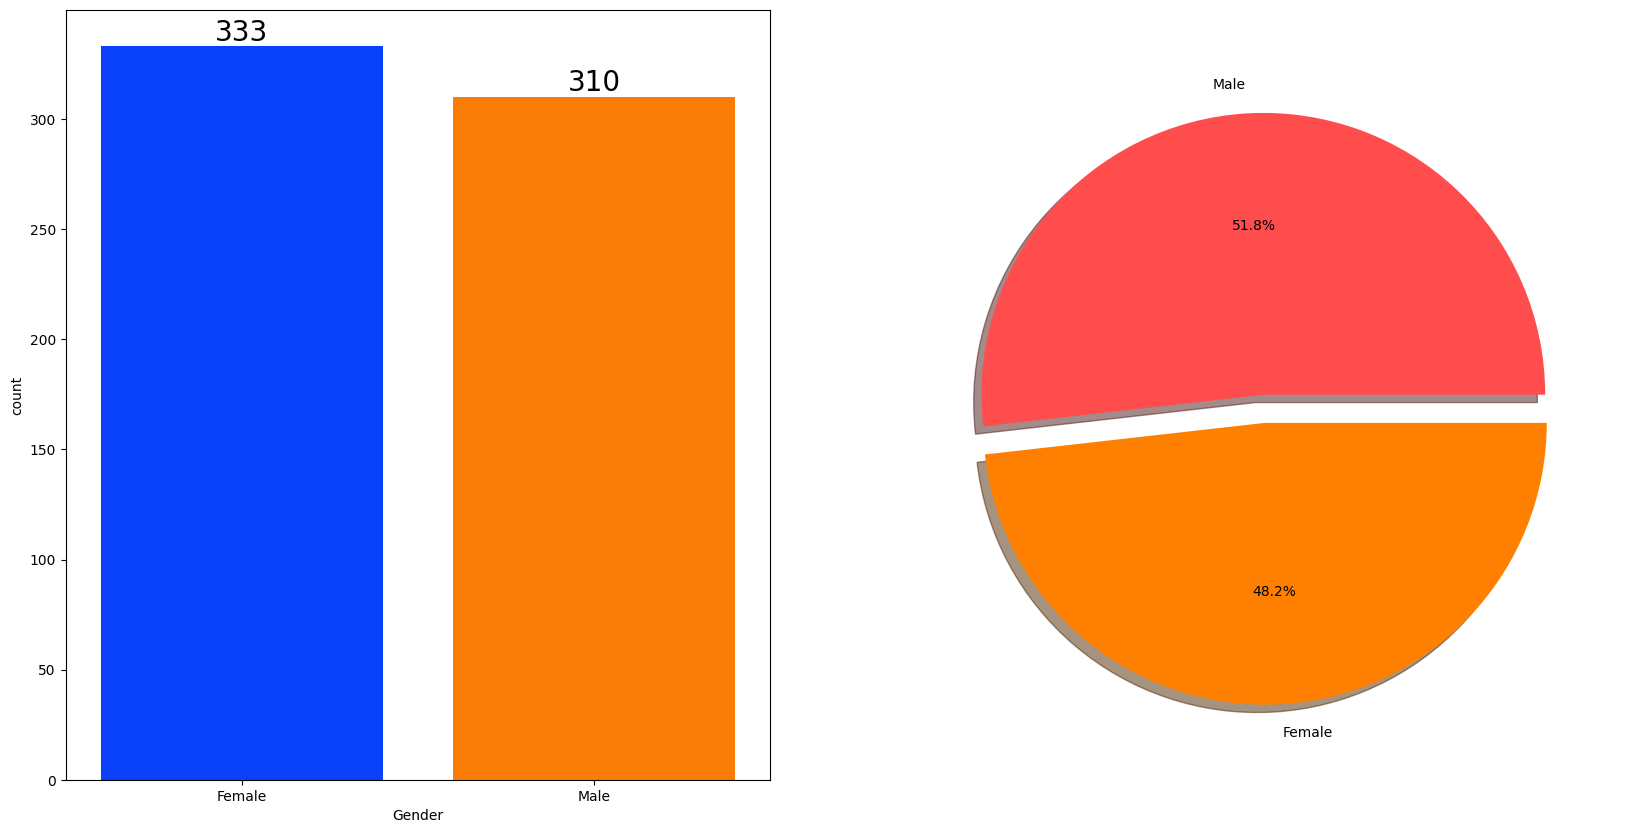

In [54]:
# How How is distribution of Dender?

f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['Gender'],data=data,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=data['Gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 333 (48.2%) and male students are 310 (51.8%) 

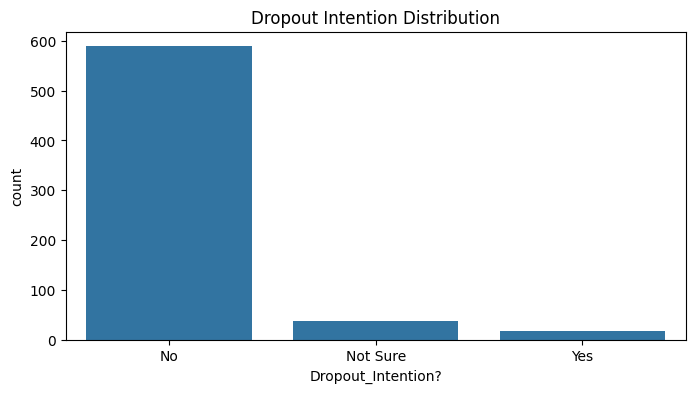

In [55]:
plt.figure(figsize=(8,4))
sns.countplot(x='Dropout_Intention?', data=data)
plt.title('Dropout Intention Distribution')
plt.show()

### Insight 
Most students do not want to drop out

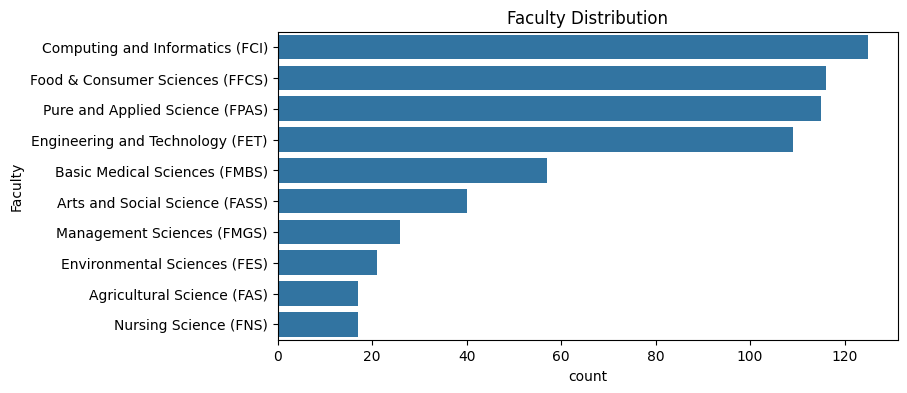

In [56]:
plt.figure(figsize=(8,4))
sns.countplot(y='Faculty', data=data, order=data['Faculty'].value_counts().index)
plt.title('Faculty Distribution')
plt.show()


### Insight
FCI has a highest number of students filled the form, followed by FFCS, and nursing has the lowest responses

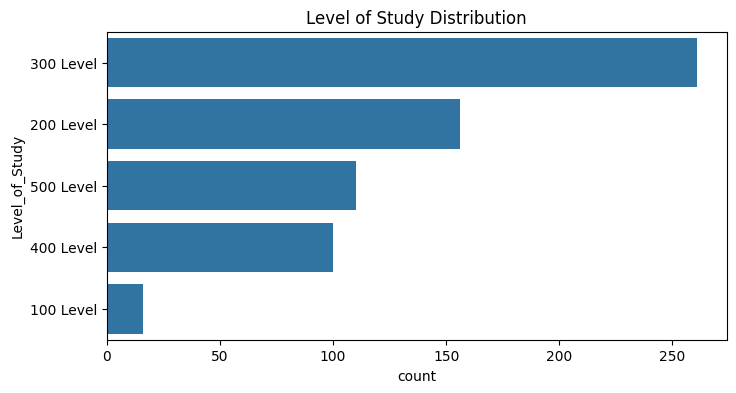

In [57]:
plt.figure(figsize=(8,4))
sns.countplot(y='Level_of_Study', data=data, order=data['Level_of_Study'].value_counts().index)
plt.title('Level of Study Distribution')
plt.show()

### Insight
300 Level filled the form most

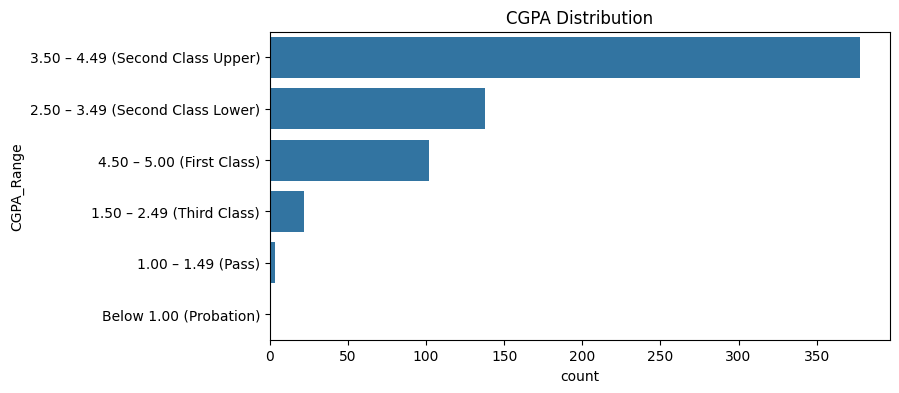

In [58]:
plt.figure(figsize=(8,4))
sns.countplot(y='CGPA_Range', data=data, order=data['CGPA_Range'].value_counts().index)
plt.title('CGPA Distribution')
plt.show()

### Insight
Students with the cgpa of range second class upper are the most followed by second class lower the followed by first class and the last is the pass

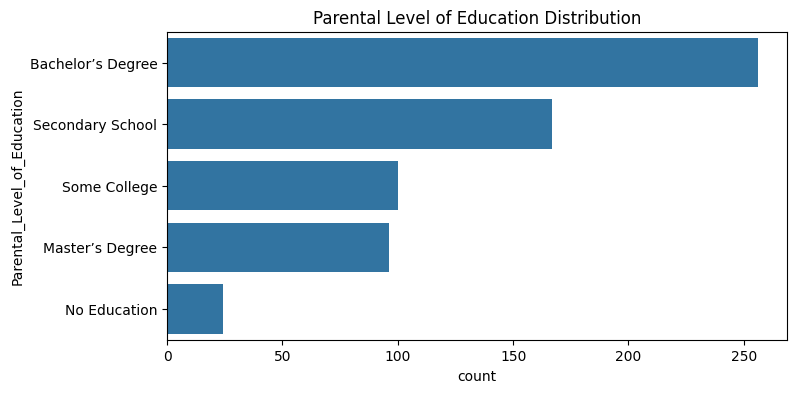

In [59]:
plt.figure(figsize=(8,4))
sns.countplot(y='Parental_Level_of_Education', data=data, order=data['Parental_Level_of_Education'].value_counts().index)
plt.title('Parental Level of Education Distribution')
plt.show()

### Insight 
Most parents have Bachelor's degree and the least is master's degree

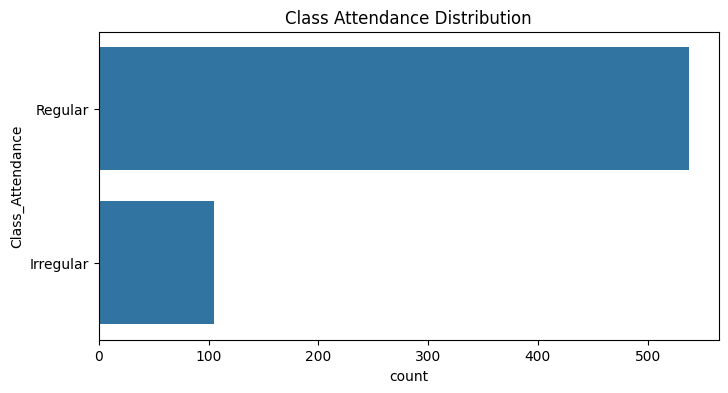

In [60]:
plt.figure(figsize=(8,4))
sns.countplot(y='Class_Attendance', data=data, order=data['Class_Attendance'].value_counts().index)
plt.title('Class Attendance Distribution')
plt.show()

### Insight and Observation
Most students attend class regularly

## Bivariate analysis (Categorical vs Target)
**Histogram** and 
**Kernel Distribution Function (KDF)**

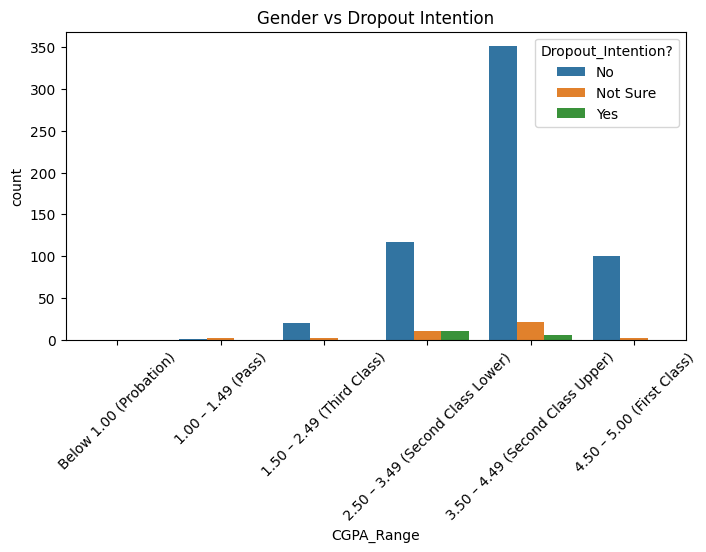

Percentage of Dropout Intention by CGPA Range:

Dropout_Intention?                       No   Not Sure       Yes
CGPA_Range                                                      
1.00 – 1.49 (Pass)                33.333333  66.666667  0.000000
1.50 – 2.49 (Third Class)         90.909091   9.090909  0.000000
2.50 – 3.49 (Second Class Lower)  84.782609   7.246377  7.971014
3.50 – 4.49 (Second Class Upper)  92.857143   5.555556  1.587302
4.50 – 5.00 (First Class)         98.039216   1.960784  0.000000


In [61]:
plt.figure(figsize=(8,4))
sns.countplot(x='CGPA_Range', hue='Dropout_Intention?', data=data)
plt.xticks(rotation=45)
plt.title('Gender vs Dropout Intention')
plt.show()

cgpa_crosstab = pd.crosstab(data['CGPA_Range'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by CGPA Range:\n")
print(cgpa_crosstab)

### Insight and Observation
Female students tend to have higher CGPA scores than male students

### Categorical Features VS Dropout_Intention

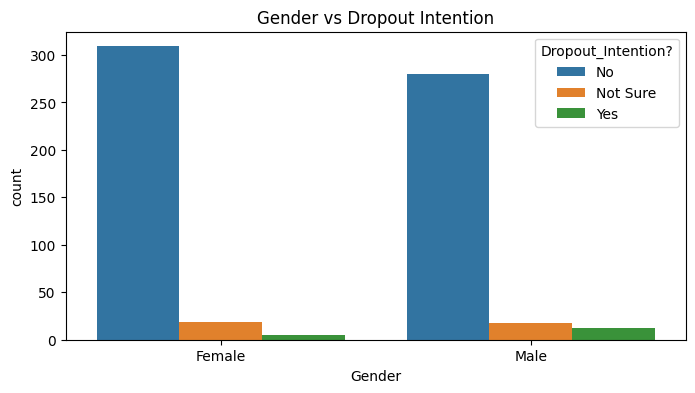

Percentage of Dropout Intention by Gender:

Dropout_Intention?         No  Not Sure       Yes
Gender                                           
Female              92.792793  5.705706  1.501502
Male                90.322581  5.806452  3.870968


In [62]:
# Gender Vs Target
plt.figure(figsize=(8,4))
sns.countplot(x='Gender', hue='Dropout_Intention?', data=data)
plt.title('Gender vs Dropout Intention')
plt.show()

gender_crosstab = pd.crosstab(data['Gender'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Gender:\n")
print(gender_crosstab)

### Insight
Female students tend to have lower dropout intention than male students.

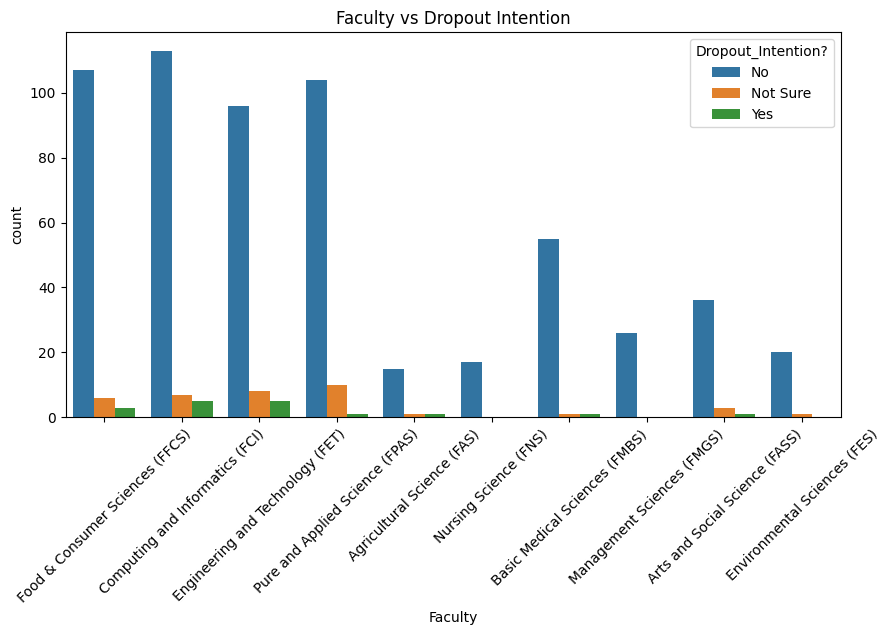

Percentage of Dropout Intention by Faculty:

Dropout_Intention?                        No  Not Sure       Yes
Faculty                                                         
Agricultural Science (FAS)         88.235294  5.882353  5.882353
Arts and Social Science (FASS)     90.000000  7.500000  2.500000
Basic Medical Sciences (FMBS)      96.491228  1.754386  1.754386
Computing and Informatics (FCI)    90.400000  5.600000  4.000000
Engineering and Technology (FET)   88.073394  7.339450  4.587156
Environmental Sciences (FES)       95.238095  4.761905  0.000000
Food & Consumer Sciences (FFCS)    92.241379  5.172414  2.586207
Management Sciences (FMGS)        100.000000  0.000000  0.000000
Nursing Science (FNS)             100.000000  0.000000  0.000000
Pure and Applied Science (FPAS)    90.434783  8.695652  0.869565


In [63]:
plt.figure(figsize=(10,5))
sns.countplot(x='Faculty', hue='Dropout_Intention?', data=data)
plt.xticks(rotation=45)
plt.title('Faculty vs Dropout Intention')
plt.show()

faculty_crosstab = pd.crosstab(data['Faculty'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Faculty:\n")
print(faculty_crosstab)



### Insight
Students in 'Faculty of Agricultural Science (FAS)' show slightly higher dropout intention than other faculties.

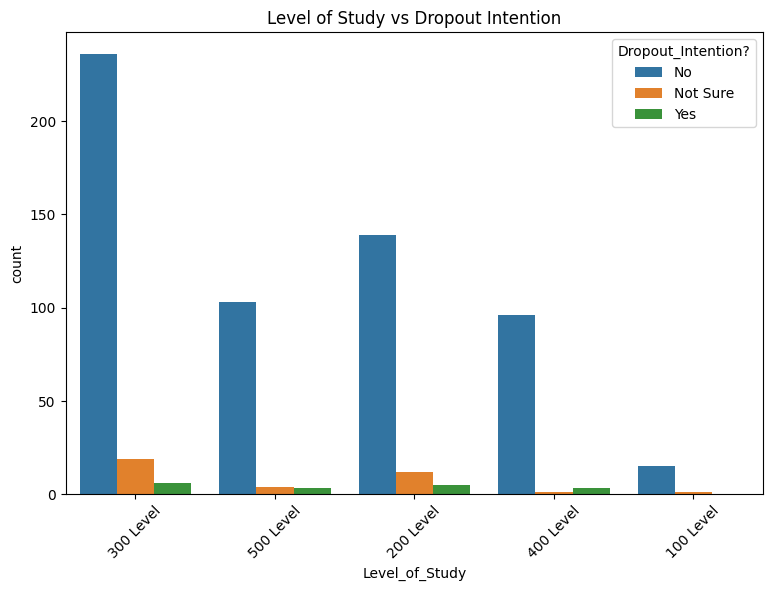

Percentage of Dropout Intention by Level of Study:

Dropout_Intention?         No  Not Sure       Yes
Level_of_Study                                   
100 Level           93.750000  6.250000  0.000000
200 Level           89.102564  7.692308  3.205128
300 Level           90.421456  7.279693  2.298851
400 Level           96.000000  1.000000  3.000000
500 Level           93.636364  3.636364  2.727273


In [64]:
plt.figure(figsize=(9, 6))
sns.countplot(x="Level_of_Study", hue="Dropout_Intention?", data=data)
plt.xticks(rotation=45)
plt.title("Level of Study vs Dropout Intention")
plt.show()

level_of_study_crosstab = pd.crosstab(data["Level_of_Study"], data["Dropout_Intention?"], normalize="index")*100
print("Percentage of Dropout Intention by Level of Study:\n")
print(level_of_study_crosstab)

### Insight
Students in 200 and 300 Level show higher dropout intention than other levels

In [65]:
data['Parental_Level_of_Education'].unique()

['Secondary School', 'No Education', 'Bachelor’s Degree', 'Some College', 'Master’s Degree']
Categories (5, str): ['No Education' < 'Secondary School' < 'Some College' < 'Bachelor’s Degree' < 'Master’s Degree']

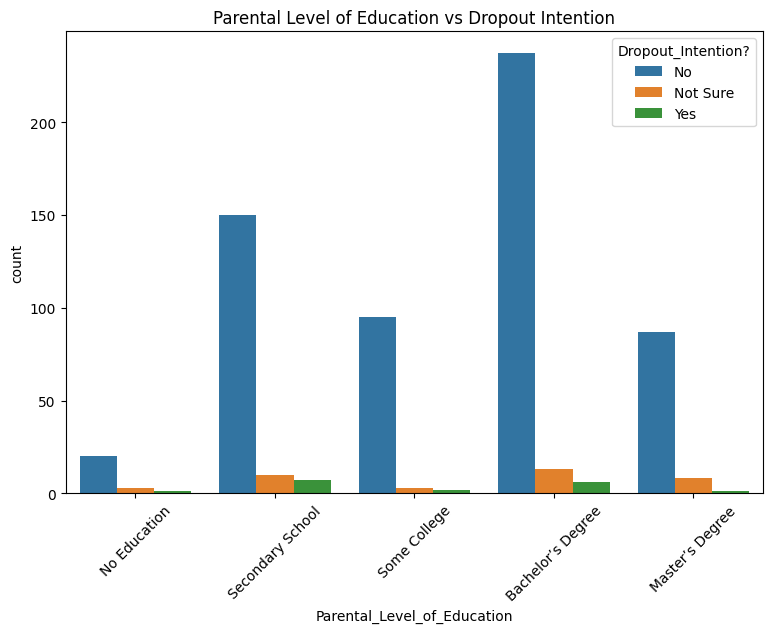

Percentage of Dropout Intention by Parental Level of Education:

Dropout_Intention?                  No   Not Sure       Yes
Parental_Level_of_Education                                
No Education                 83.333333  12.500000  4.166667
Secondary School             89.820359   5.988024  4.191617
Some College                 95.000000   3.000000  2.000000
Bachelor’s Degree            92.578125   5.078125  2.343750
Master’s Degree              90.625000   8.333333  1.041667


In [66]:
plt.figure(figsize=(9, 6))
sns.countplot(x="Parental_Level_of_Education", hue="Dropout_Intention?", data=data)
plt.xticks(rotation=45)
plt.title("Parental Level of Education vs Dropout Intention")
plt.show()

parental_level_of_education_crosstab = pd.crosstab(data["Parental_Level_of_Education"], data["Dropout_Intention?"], normalize="index")*100
print("Percentage of Dropout Intention by Parental Level of Education:\n")
print(parental_level_of_education_crosstab)

### Insight 
Students with the parental level of education of secondary school and none show higher dropout intention than other faculties

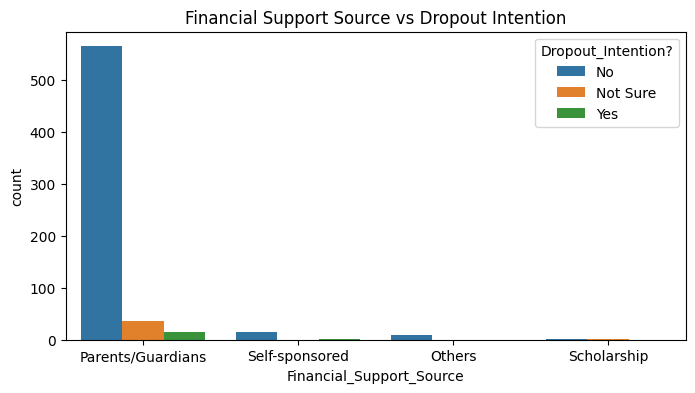

Percentage of Dropout Intention by Financial Support Source:

Dropout_Intention?                No   Not Sure        Yes
Financial_Support_Source                                  
Others                    100.000000   0.000000   0.000000
Parents/Guardians          91.707317   5.853659   2.439024
Scholarship                66.666667  33.333333   0.000000
Self-sponsored             87.500000   0.000000  12.500000


In [67]:
plt.figure(figsize=(8,4))
sns.countplot(x='Financial_Support_Source', hue='Dropout_Intention?', data=data)
plt.title('Financial Support Source vs Dropout Intention')
plt.show()

fs_crosstab = pd.crosstab(data['Financial_Support_Source'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Financial Support Source:\n")
print(fs_crosstab)

### Insight
Students depending solely on personal support have higher dropout intention compared to others.

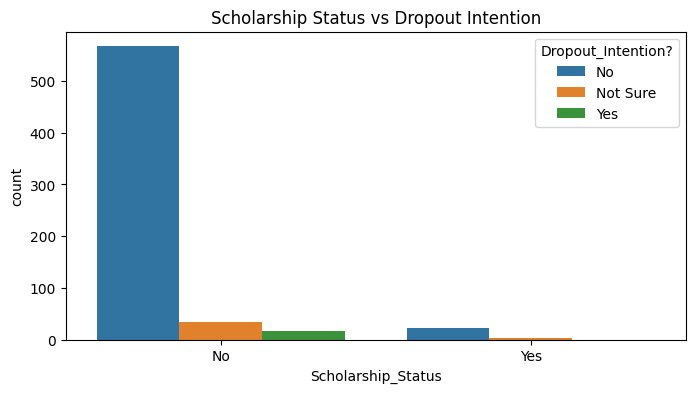

Percentage of Dropout Intention by Scholarship Status:

Dropout_Intention?         No   Not Sure       Yes
Scholarship_Status                                
No                  91.747573   5.501618  2.750809
Yes                 88.000000  12.000000  0.000000


In [68]:
plt.figure(figsize=(8,4))
sns.countplot(x='Scholarship_Status', hue='Dropout_Intention?', data=data)
plt.title('Scholarship Status vs Dropout Intention')
plt.show()

scholar_crosstab = pd.crosstab(data['Scholarship_Status'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Scholarship Status:\n")
print(scholar_crosstab)

### Insight
Students without scholarships show slightly higher dropout intention.

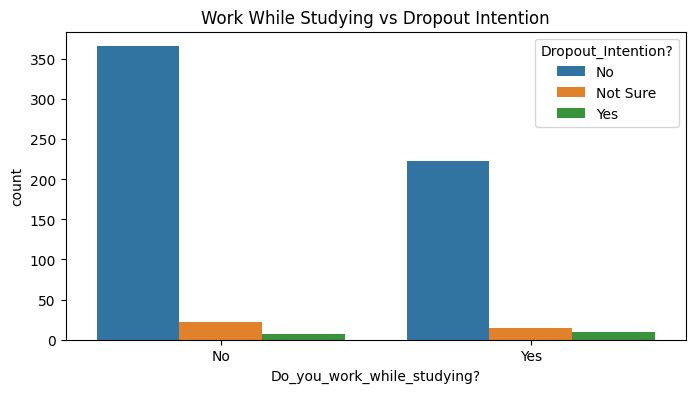

Percentage of Dropout Intention by Work Status:

Dropout_Intention?                  No  Not Sure       Yes
Do_you_work_while_studying?                               
No                           92.658228  5.569620  1.772152
Yes                          89.919355  6.048387  4.032258


In [69]:
plt.figure(figsize=(8,4))
sns.countplot(x='Do_you_work_while_studying?', hue='Dropout_Intention?', data=data)
plt.title('Work While Studying vs Dropout Intention')
plt.show()

work_crosstab = pd.crosstab(data['Do_you_work_while_studying?'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Work Status:\n")
print(work_crosstab)

### Insight:
 Students who work while studying have slightly higher dropout intention.

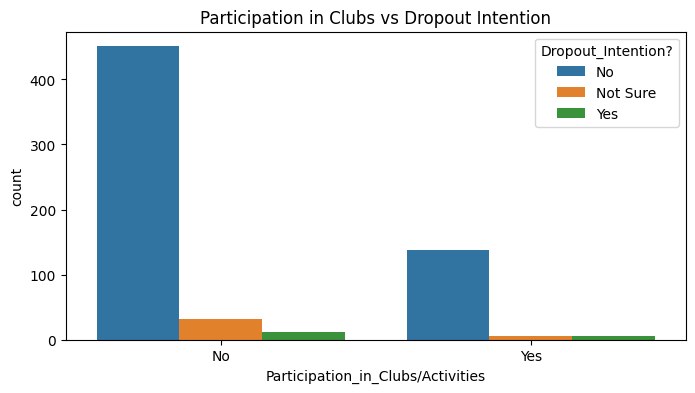

Percentage of Dropout Intention by Participation in Clubs:

Dropout_Intention?                        No  Not Sure       Yes
Participation_in_Clubs/Activities                               
No                                 91.295547  6.275304  2.429150
Yes                                92.617450  4.026846  3.355705


In [70]:
plt.figure(figsize=(8,4))
sns.countplot(x='Participation_in_Clubs/Activities', hue='Dropout_Intention?', data=data)
plt.title('Participation in Clubs vs Dropout Intention')
plt.show()

club_crosstab = pd.crosstab(data['Participation_in_Clubs/Activities'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Participation in Clubs:\n")
print(club_crosstab)

### Insight:
Students participate in clubs have higher dropout intention. 

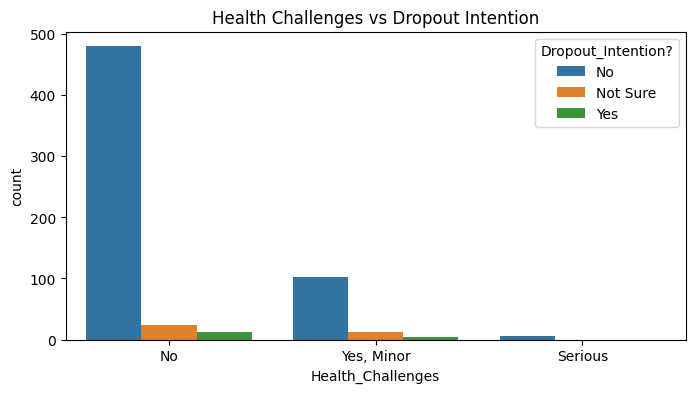

Percentage of Dropout Intention by Health Challenges:

Dropout_Intention?          No   Not Sure       Yes
Health_Challenges                                  
No                   93.023256   4.651163  2.325581
Serious             100.000000   0.000000  0.000000
Yes, Minor           85.123967  10.743802  4.132231


In [71]:
plt.figure(figsize=(8,4))
sns.countplot(x='Health_Challenges', hue='Dropout_Intention?', data=data)
plt.title('Health Challenges vs Dropout Intention')
plt.show()

health_crosstab = pd.crosstab(data['Health_Challenges'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Health Challenges:\n")
print(health_crosstab)

### Insight:
Serious health issues don’t show strong correlation with dropout intention.

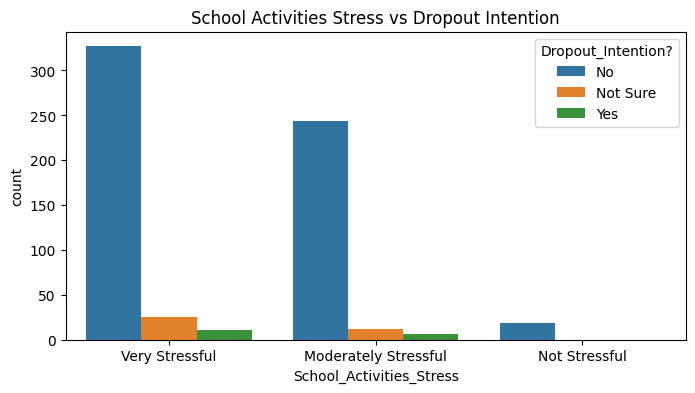

Percentage of Dropout Intention by Stress Level:

Dropout_Intention?                No  Not Sure       Yes
School_Activities_Stress                                
Moderately Stressful       93.129771  4.580153  2.290076
Not Stressful             100.000000  0.000000  0.000000
Very Stressful             90.082645  6.887052  3.030303


In [72]:
## School Activities Stress vs Target
plt.figure(figsize=(8,4))
sns.countplot(x='School_Activities_Stress', hue='Dropout_Intention?', data=data)
plt.title('School Activities Stress vs Dropout Intention')
plt.show()

stress_crosstab = pd.crosstab(data['School_Activities_Stress'], data['Dropout_Intention?'], normalize='index')*100
print("Percentage of Dropout Intention by Stress Level:\n")
print(stress_crosstab)

### Insight:
Students reporting very high stress levels tend to have slightly higher dropout intention.

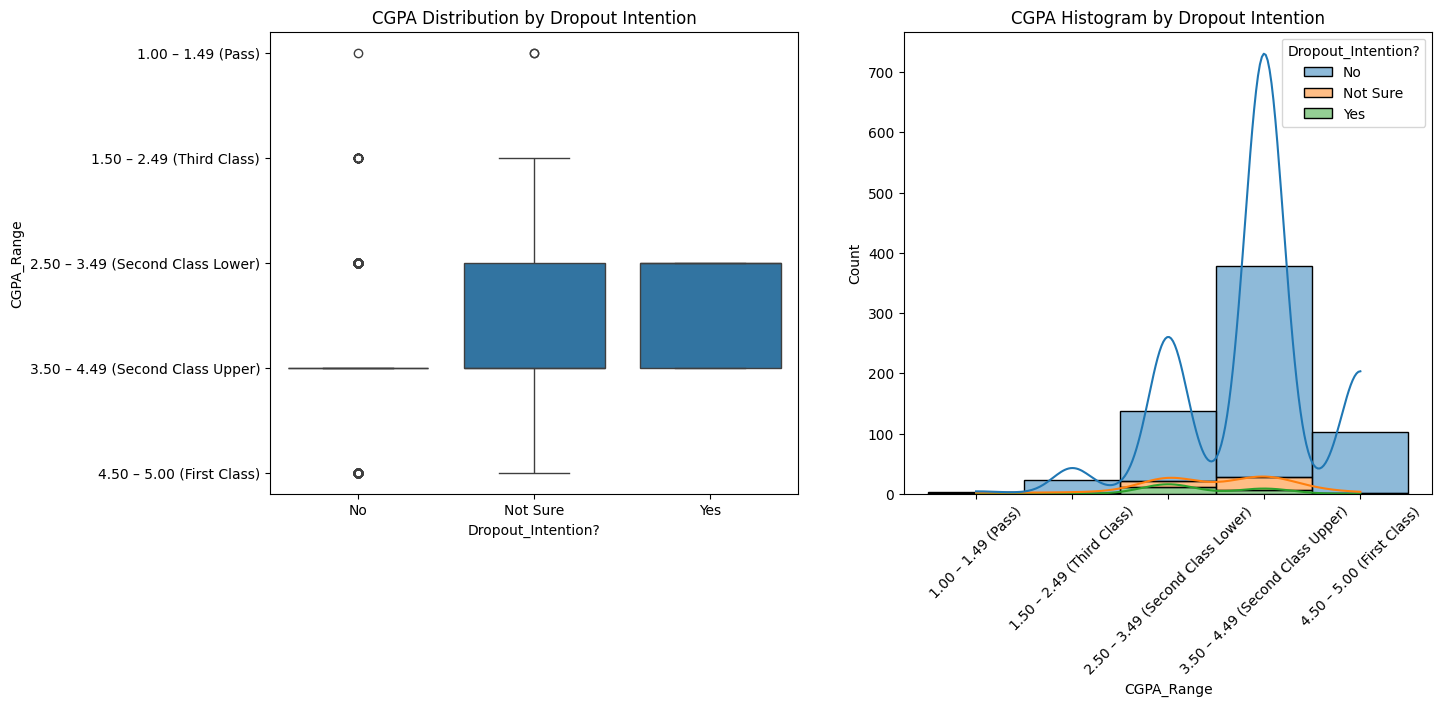

CGPA Statistics by Dropout Intention:

                   count unique                               top freq
Dropout_Intention?                                                    
No                   589      5  3.50 – 4.49 (Second Class Upper)  351
Not Sure              37      5  3.50 – 4.49 (Second Class Upper)   21
Yes                   17      2  2.50 – 3.49 (Second Class Lower)   11


In [73]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.boxplot(x='Dropout_Intention?', y='CGPA_Range', data=data)
plt.title('CGPA Distribution by Dropout Intention')

plt.subplot(122)
sns.histplot(data=data, x='CGPA_Range', kde=True, hue='Dropout_Intention?', multiple='stack')
plt.xticks(rotation=45)
plt.title('CGPA Histogram by Dropout Intention')

plt.show()

print("CGPA Statistics by Dropout Intention:\n")
print(data.groupby('Dropout_Intention?')['CGPA_Range'].describe())

### Insight:
- Students with higher CGPA are less likely to intend to dropout.
- Dropout group concentrated in lower CGPA ranges.

In [74]:
data.columns

Index(['Gender', 'Age_Range', 'Admission_Year', 'Faculty', 'Level_of_Study',
       'Parental_Level_of_Education', 'Financial_Support_Source', 'CGPA_Range',
       'Hours_of_Study_per_Week', 'Class_Attendance', 'Accommodation_Type',
       'Do_you_work_while_studying?', 'Internet_Access',
       'Participation_in_Clubs/Activities', 'Scholarship_Status',
       'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?',
       'Health_Challenges', 'School_Activities_Stress', 'Dropout_Intention?',
       'CGPA_Num', 'Parental_Education_Num', 'Hours_of_Study_Num',
       'Class_Attendance_Num', 'Dropout_Intention_Num', 'Dropout_Risk'],
      dtype='str')

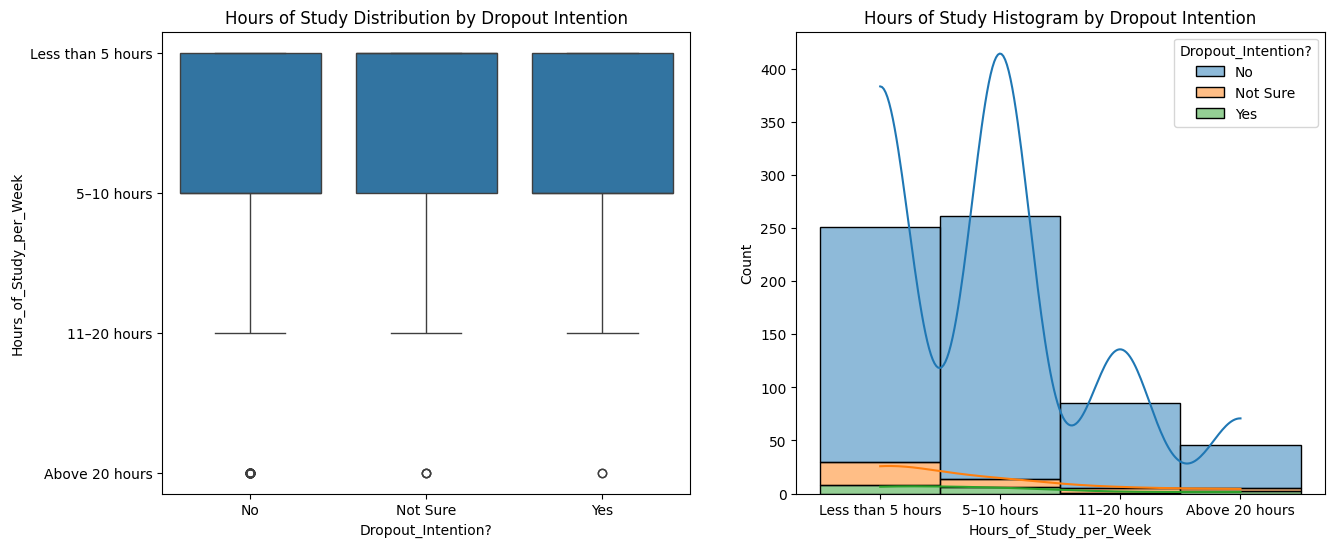

Hours of Study Statistics by Dropout Intention:

                   count unique                top freq
Dropout_Intention?                                     
No                   589      4         5–10 hours  247
Not Sure              37      4  Less than 5 hours   22
Yes                   17      4  Less than 5 hours    8


In [75]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.boxplot(x='Dropout_Intention?', y='Hours_of_Study_per_Week', data=data)
plt.title('Hours of Study Distribution by Dropout Intention')

plt.subplot(122)
sns.histplot(data=data, x='Hours_of_Study_per_Week', kde=True, hue='Dropout_Intention?', multiple='stack')
plt.title('Hours of Study Histogram by Dropout Intention')

plt.show()

print("Hours of Study Statistics by Dropout Intention:\n")
print(data.groupby('Dropout_Intention?')['Hours_of_Study_per_Week'].describe())

### Insight:
Students who study more hours per week are less likely to intend to dropout.

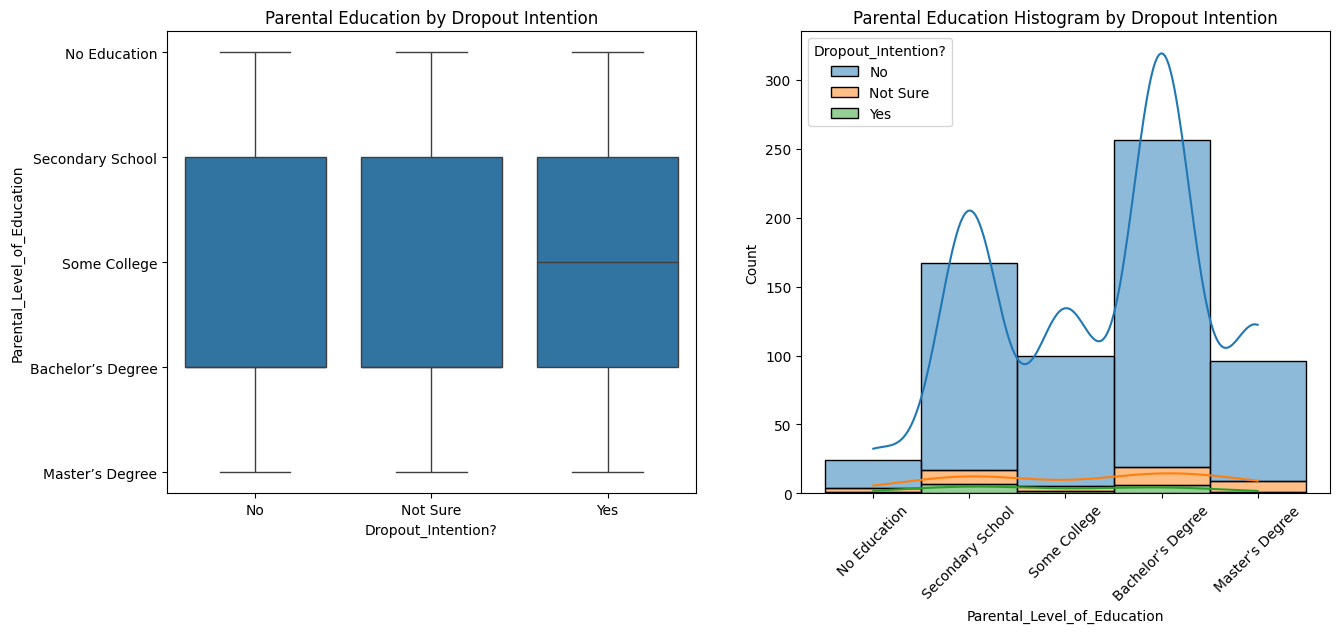

Parental Education Statistics by Dropout Intention:

                   count unique                top freq
Dropout_Intention?                                     
No                   589      5  Bachelor’s Degree  237
Not Sure              37      5  Bachelor’s Degree   13
Yes                   17      5   Secondary School    7


In [76]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

# First subplot
plt.subplot(121)
sns.boxplot(x='Dropout_Intention?', y='Parental_Level_of_Education', data=data)
plt.title('Parental Education by Dropout Intention')

# Second subplot
plt.subplot(122)
plt.xticks(rotation=(45))
sns.histplot(data=data, x='Parental_Level_of_Education', kde=True, hue='Dropout_Intention?', multiple='stack')
plt.title('Parental Education Histogram by Dropout Intention')

plt.show()

print("Parental Education Statistics by Dropout Intention:\n")
print(data.groupby('Dropout_Intention?')['Parental_Level_of_Education'].describe())

### Insight:
 Higher parental education appears associated with lower dropout intention.

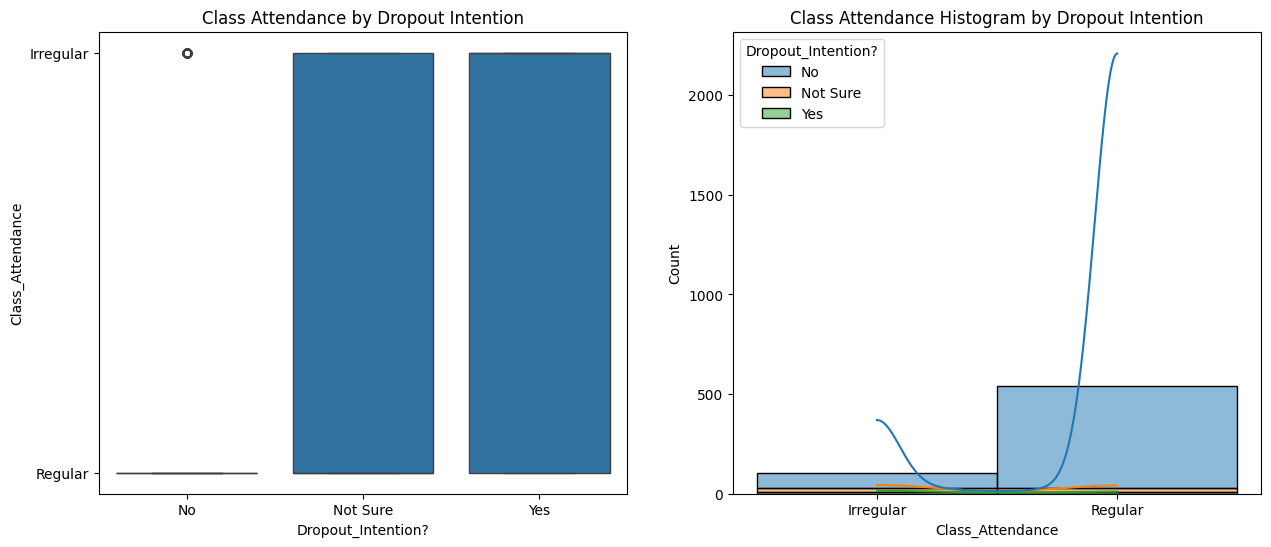

Class Attendance Statistics by Dropout Intention:

                   count unique        top freq
Dropout_Intention?                             
No                   589      2    Regular  512
Not Sure              37      2    Regular   19
Yes                   17      2  Irregular   10


In [77]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))

plt.subplot(121)
sns.boxplot(x='Dropout_Intention?', y='Class_Attendance', data=data)
plt.title('Class Attendance by Dropout Intention')

plt.subplot(122)
sns.histplot(data=data, x='Class_Attendance', kde=True, hue='Dropout_Intention?', multiple='stack')
plt.title('Class Attendance Histogram by Dropout Intention')

plt.show()

print("Class Attendance Statistics by Dropout Intention:\n")
print(data.groupby('Dropout_Intention?')['Class_Attendance'].describe())

### Insight:
- Irregular attendees are more likely to intend to dropout.
- Regular attendees dominate the non-dropout group.

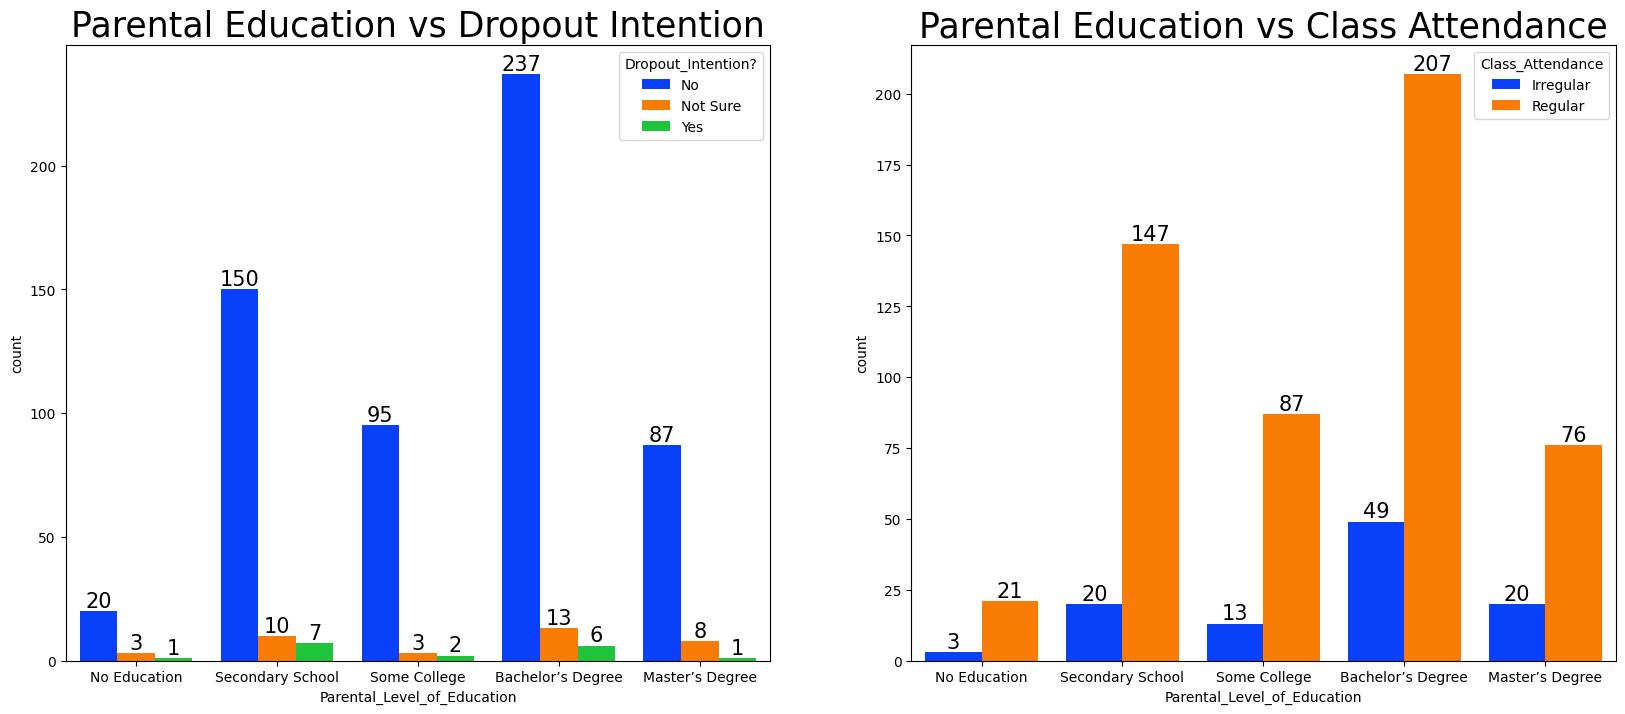

In [78]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Subplot 1: Parental Education vs Dropout Intention
sns.countplot(
    x=data['Parental_Level_of_Education'],
    data=data,
    palette='bright',
    hue='Dropout_Intention?',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Parental Education vs Dropout Intention', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Subplot 2: Optional: Parental Education vs Another Feature (e.g., Class Attendance)
sns.countplot(
    x=data['Parental_Level_of_Education'],
    data=data,
    palette='bright',
    hue='Class_Attendance',
    saturation=0.95,
    ax=ax[1]
)
ax[1].set_title('Parental Education vs Class Attendance', color='black', size=25)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

plt.show()

### Insight:
-Students whose parents have higher education (Bachelor’s/Master’s) show lower dropout intention.

-Dropout intention is higher for students whose parents have secondary education or none.

-This indicates parental education is an important factor influencing dropout intention.

## Multivariate Analysis Using Pieplot 

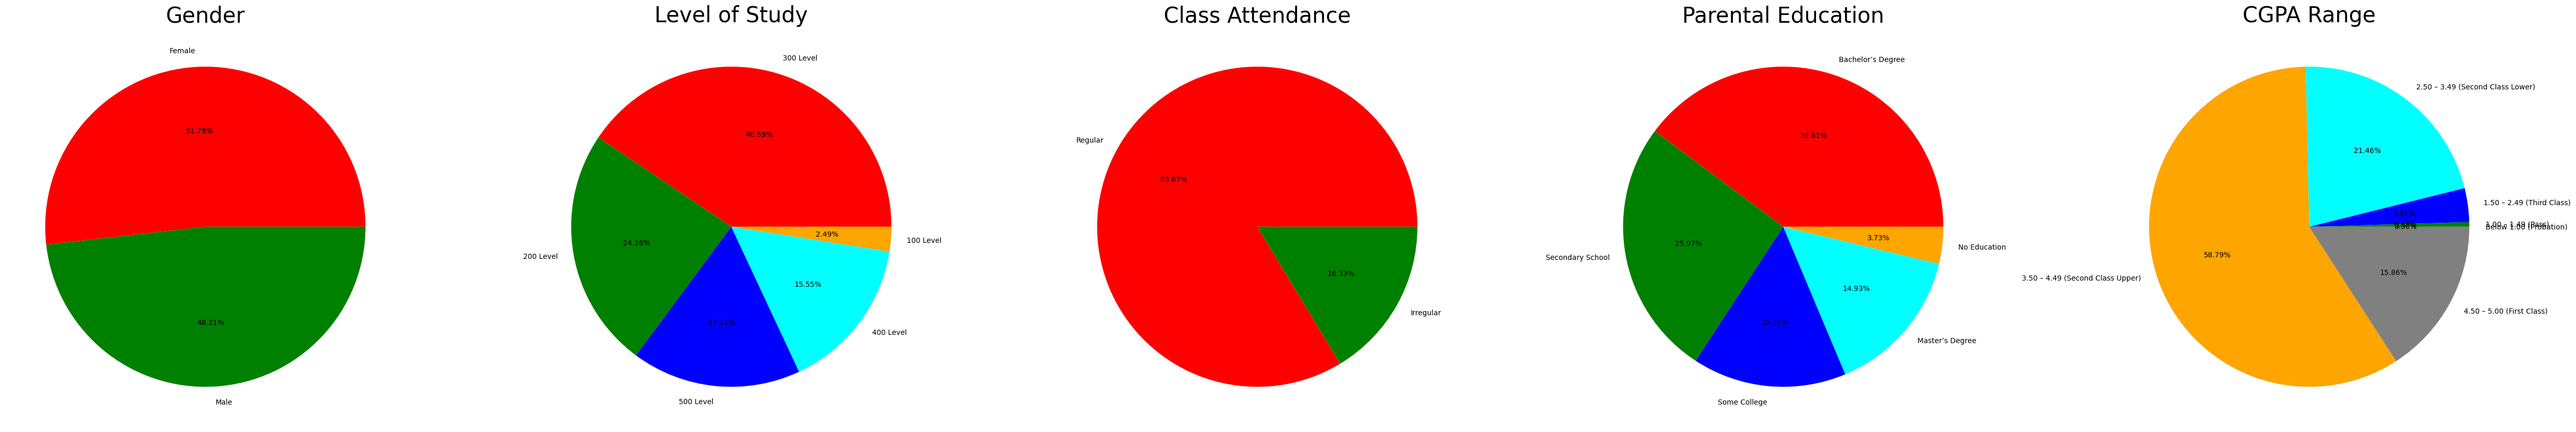

In [79]:
# Set figure size
plt.rcParams['figure.figsize'] = (50, 20)

# --- Gender ---
plt.subplot(1, 5, 1)
size = data['Gender'].value_counts()
labels = size.index  # automatically gets 'Female', 'Male'
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=30)
plt.axis('off')

# --- Level of Study ---
plt.subplot(1, 5, 2)
size = data['Level_of_Study'].value_counts()
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Level of Study', fontsize=30)
plt.axis('off')

# --- Class Attendance ---
plt.subplot(1, 5, 3)
size = data['Class_Attendance'].value_counts()
labels = size.index
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Class Attendance', fontsize=30)
plt.axis('off')

# --- Parental Education ---
plt.subplot(1, 5, 4)
size = data['Parental_Level_of_Education'].value_counts()
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=30)
plt.axis('off')

# --- CGPA Range ---
plt.subplot(1, 5, 5)
size = data['CGPA_Range'].value_counts().sort_index()  # keeps ordinal order
labels = size.index
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey'][:len(labels)]
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('CGPA Range', fontsize=30)
plt.axis('off')

plt.tight_layout()
plt.show()

#####  Insights
- Number of Male and Female students are almost equal
- Number students are greatest in 300 Level
- Number of students who attend class regular are greater
- Number of students whose parental level of education education is "Secondary School" is greater followed closely by "Master's degree"
- Number of students who in second class upper are greater

## Correlation heatmap

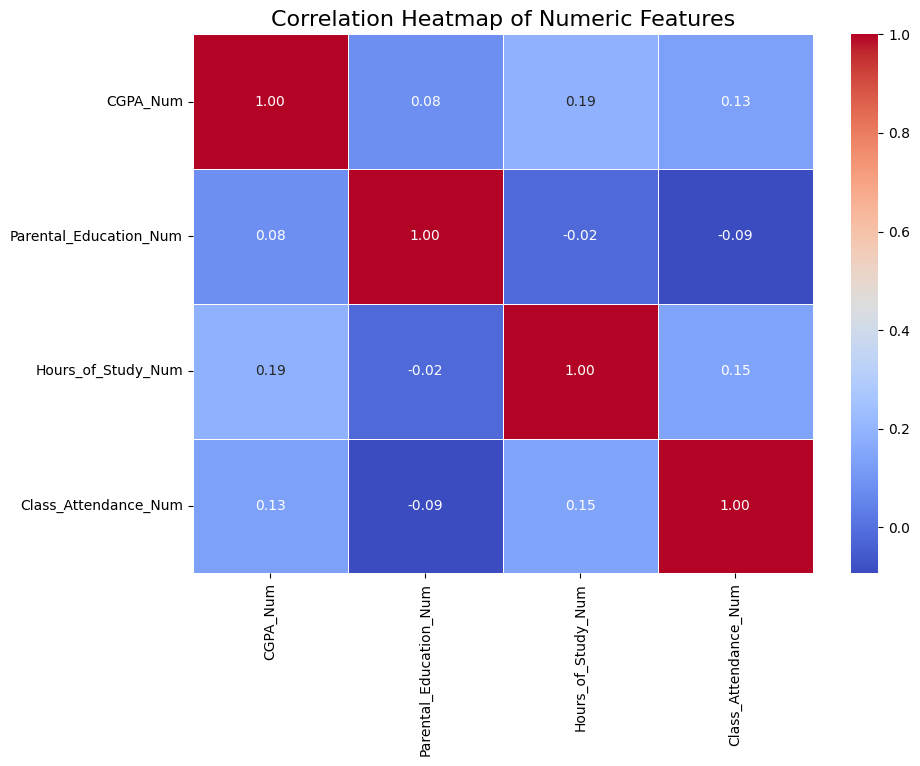

In [80]:
# Compute correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(data[num_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.show()

### Insight:
Numeric features show strong positive correlations, indicating that higher study hours, class attendance, and CGPA tend to increase together

## Checking Outlier

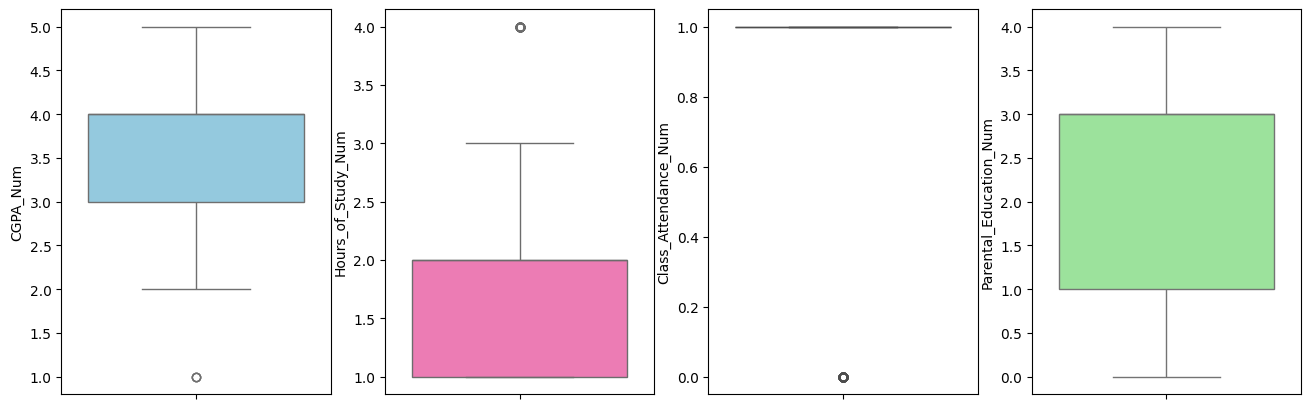

In [81]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(data['CGPA_Num'],color='skyblue')
plt.subplot(142)
sns.boxplot(data['Hours_of_Study_Num'],color='hotpink')
plt.subplot(143)
sns.boxplot(data['Class_Attendance_Num'],color='yellow')
plt.subplot(144)
sns.boxplot(data['Parental_Education_Num'],color='lightgreen')
plt.show()

## Boxplot of numerical features vs target

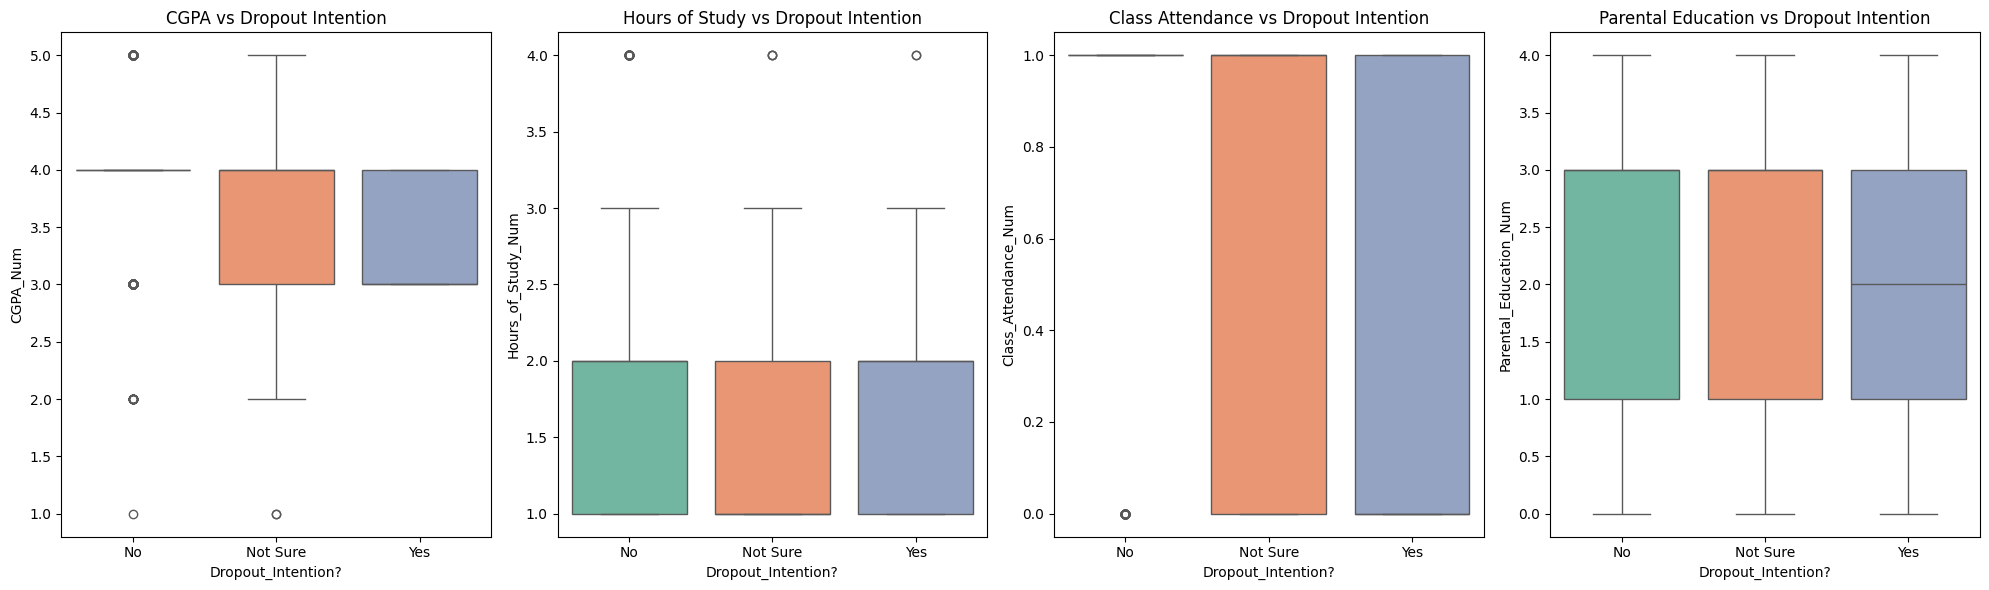

In [82]:
plt.figure(figsize=(20,6))

plt.subplot(1,4,1)
sns.boxplot(x='Dropout_Intention?', y='CGPA_Num', data=data, palette='Set2')
plt.title('CGPA vs Dropout Intention')

plt.subplot(1,4,2)
sns.boxplot(x='Dropout_Intention?', y='Hours_of_Study_Num', data=data, palette='Set2')
plt.title('Hours of Study vs Dropout Intention')

plt.subplot(1,4,3)
sns.boxplot(x='Dropout_Intention?', y='Class_Attendance_Num', data=data, palette='Set2')
plt.title('Class Attendance vs Dropout Intention')

plt.subplot(1,4,4)
sns.boxplot(x='Dropout_Intention?', y='Parental_Education_Num', data=data, palette='Set2')
plt.title('Parental Education vs Dropout Intention')

plt.tight_layout()
plt.show()

### Insight:
**1 CGPA vs Dropout Intention**

Students who intend to drop out generally have lower CGPA values.

There is a clear separation between high-performing and low-performing students in relation to dropout intention.

**2. Hours of Study per Week vs Dropout Intention**

   Students intending to stay tend to study more hours per week.
   
   Dropout-intending students cluster at lower study hours, indicating a potential link between study habit and persistence.

**4. Class Attendance vs Dropout Intention**

   Higher attendance is associated with lower dropout intention.
   
   Students with poor attendance show a higher likelihood of intending to drop out.

**6. Parental Level of Education vs Dropout Intention**
   
   Students whose parents have higher education levels tend to show lower dropout intention.
   
   Lower parental education levels are slightly correlated with higher dropout intention, suggesting a socio-educational influence.

## Pairplot

<Figure size 500x300 with 0 Axes>

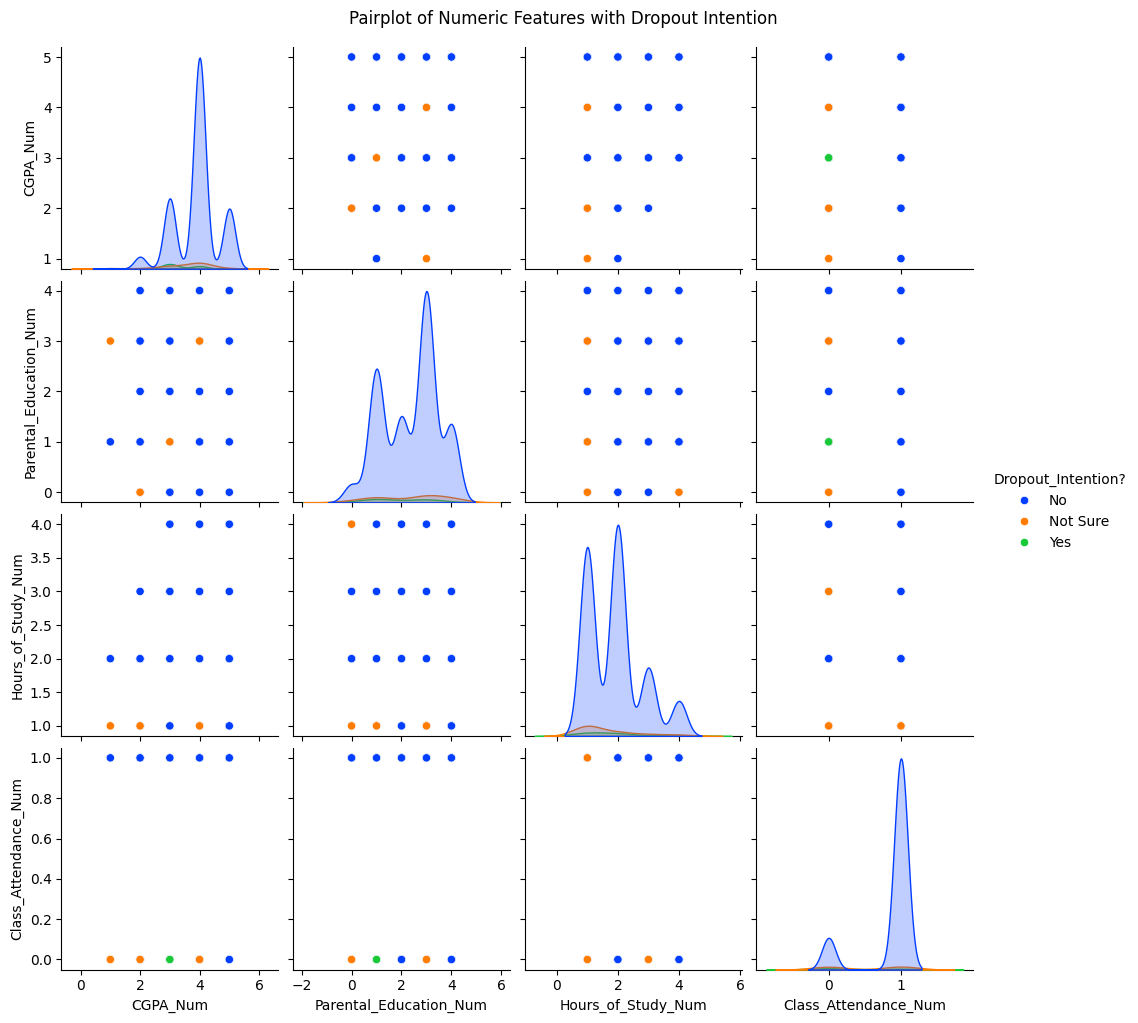

In [83]:
plt.figure(figsize=(5,3))
sns.pairplot(data=data[num_features + ['Dropout_Intention?']], 
             hue='Dropout_Intention?', 
             palette='bright')
plt.suptitle("Pairplot of Numeric Features with Dropout Intention", fontsize=12, y=1.02)
plt.show()

### Insight:
From the pairplot, it is clear that students with higher CGPA,level of parent education, more hours of study per week, and better class attendance tend to have lower dropout intention.

## Conclusion:
- Student Performance and Dropout Intention: CGPA, hours of study per week, and class attendance are strong indicators of dropout intention; students with lower scores, fewer study hours, or poor attendance are more likely to consider dropping out.

- Gender Differences: Female students tend to perform better than male students across all measured outcomes.

- Parental Influence: Higher parental education levels are associated with better student performance and lower dropout intention, showing a socio-educational effect.

- Targeted Factors: While features like test preparation course participation show minor effects on performance, finishing the course may still provide marginal benefits.

- Correlation Insights: Numeric features such as CGPA, study hours, and attendance are positively correlated, indicating that better engagement in one area tends to reflect in overall performance.

## Overall Observation:

Student performance is multifactorial, influenced by gender, parental education, study habits, and attendance. These insights can guide interventions to improve student outcomes and reduce dropout risk.

In [84]:
data.to_csv('EDA&FECleandataset.csv',index=False)